In [1]:
import boto3
import botocore
import functools
from IPython.core.display import display, HTML
from iterdub import iterdub as ib
from iterpop import iterpop as ip
import itertools as it
import json
import matplotlib
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from pandas.util import hash_pandas_object
import seaborn as sns
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyanalysis import calc_loglikelihoods_by_num_sets
from dishpylib.pyanalysis import count_hands_with_k_or_more_sets
from dishpylib.pyanalysis import count_hands_without_k_or_more_sets
from dishpylib.pyanalysis import estimate_interpolation_complexity
from dishpylib.pyanalysis import calc_loglikelihoods_over_set_sizes
from dishpylib.pyhelpers import get_env_context
from dishpylib.pyhelpers import get_git_revision_hash
from dishpylib.pyhelpers import make_timestamp
from dishpylib.pyhelpers import NumpyEncoder
from dishpylib.pyhelpers import preprocess_competition_fitnesses
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmez679
interpreter: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
notebook name: 2025-11-30-genome-complexity-regression
notebook path: /home/runner/work/oee4/oee4/binder/2025-11-30-genome-complexity-regression.ipynb
revision: bdac574
timestamp: 2026-02-05T15:04:26Z00:00

IPython==7.16.1
packaging==25.0


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2025-11-30-genme-complexity-regression"


In [5]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")


control_competitions = bucket_handle.objects.filter(
    Prefix=f'endeavor=16/control-competitions/stage=2+what=collated/',
)


In [6]:
control_dfs = [
    pd.read_csv(
        f's3://prq49/{control_competitions.key}',
    )
    for control_competitions in control_competitions
]


In [7]:
pd.options.display.max_columns = None


In [8]:
df = pd.concat(control_dfs, ignore_index=True)
df


,Competition Stint,Competition Series,Competition Replicate,Competition Treatment,Treatment _,Treatment mut_sever,Treatment mut_freq,Treatment diversity,Treatment bucket,Competition Endeavor,Competition Repro,Competition Slurm Job ID,Competition Thread,Competition Process,Update,Population Slots,Num Live Cells,Population Extinct,Abundance,Prevalence,Root ID,Genome Slug,Genome Filename,Fitness Differential,Count,Extrospective State Target Idx,Inter Message Self-Send Filter Mod,Inter Message Self-Send Filter Target,Intermittent Extrospective State Exchange Probability,Intermittent Extrospective State Rotate Probability,Intermittent Introspective State Exchange Probability,Intermittent Introspective State Rotate Probability,Intermittent Writable State Exchange Probability,Intermittent Writable State Rotate Probability,Intra Message Self-Send Filter Mod,Intra Message Self-Send Filter Target,Introspective State Target Idx,Mutation Occurence Rate Multiplicand,Point Mutation Rate Multiplicand,Program Max Size Override,Sequence Defect Rate Multiplicand,Writable State Target Idx,genome a,genome criteria,genome ext,genome morph,genome proc,genome root_id,genome series,genome stint,genome thread,genome variation
0,0,16000,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,IXVK8LBclnMsLm7U,20699952,0,0,11081,3600,3588,0,0.508333,0.510033,1,criteria%abundance~morph%wildtype~proc%0~serie...,./root_id=1+a=genome+criteria=abundance+morph=...,9.054640e-07,1830,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,abundance,.json.gz,wildtype,0,1,16000,0,0,master
1,0,16000,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,IXVK8LBclnMsLm7U,20699952,0,0,11081,3600,3588,0,0.488333,0.489967,0,criteria%abundance~morph%wildtype~proc%0~serie...,./root_id=0+a=genome+criteria=abundance+morph=...,-9.054640e-07,1758,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,abundance,.json.gz,wildtype,0,0,16000,0,0,master
2,0,16000,1,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,JTrD6C6T6Z21iB7S,20675667,0,0,11264,3600,3591,0,0.506944,0.508215,0,criteria%abundance~morph%wildtype~proc%0~serie...,./root_id=0+a=genome+criteria=abundance+morph=...,7.293130e-07,1825,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,abundance,.json.gz,wildtype,0,0,16000,0,0,master
3,0,16000,1,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,JTrD6C6T6Z21iB7S,20675667,0,0,11264,3600,3591,0,0.490556,0.491785,1,criteria%abundance~morph%wildtype~proc%0~serie...,./root_id=1+a=genome+criteria=abundance+morph=...,-7.293130e-07,1766,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,abundance,.json.gz,wildtype,0,1,16000,0,0,master
4,0,16000,10,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,lzgBpHZMlC2oE34r,20694049,0,0,11026,3600,3594,0,0.509722,0.510573,0,criteria%abundance~morph%wildtype~proc%0~serie...,./root_id=0+a=genome+criteria=abundance+morph=...,9.589310e-07,1835,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,abundance,.json.gz,wildtype,0,0,16000,0,0,master
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20727,99,16005,7,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,nHcxnkSIfrEgVYza,25223072,0,0,4113,3600,3591,0,0.508333,0.509607,0,criteria%abundance~morph%wildtype~proc%0~serie...,./root_id=0+a=genome+criteria=abundance+morph=...,2.335850e-06,1830,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,abundance,.json.gz,wildtype,0,0,16005,99,0,master
20728,99,

In [9]:
import pandas as pd
from scipy import stats

def fit_control_t_distns(control_df):

    na_rows = control_df['Fitness Differential'].isna()
    assert all( control_df[ na_rows ]['Population Extinct'] )
    control_df['Fitness Differential'].fillna(0, inplace=True,)

    res = []
    for series in control_df['Competition Series'].unique():

        series_df = control_df[ control_df['Competition Series'] == series ]

        # legacy data was mixed inside of the variant_df
        # wt_vs_wt_df = series_df.groupby('Competition Repro').filter(
        #     lambda x: (x['genome variation'] == 'master').all()
        # ).groupby('Competition Repro').first().reset_index()

        # fit a t distribution to the control data
        # df is degrees of freedom
        df, loc, scale = stats.t.fit( series_df['Fitness Differential'] )


        res.append({
            'Series' : series,
            'Fit Degrees of Freedom' : df,
            'Fit Loc' : loc,
            'Fit Scale' : scale,
        })

    return pd.DataFrame(res)


In [10]:
import boto3
import botocore
import functools
import pandas as pd

from dishpylib.pyhelpers import fit_control_t_distns

@functools.lru_cache
def get_control_t_distns( bucket, endeavor, stint ):

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/control-competitions/stage=2+what=collated/stint={stint}/',
    )

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )
    print("mean update", control_df["Update"].mean())

    return fit_control_t_distns(control_df[
        control_df["Root ID"] == 1
    ].copy())


In [11]:
import functools
from iterpop import iterpop as ip
from scipy import stats


def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: stats.t.cdf(
            row["Fitness Differential"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 50
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 50)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [12]:
pd.options.display.max_columns = None


In [13]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49')

dfs = []
for stint in range(1, 101):
# for stint in (19,):
    print(stint)
    series_profiles, = bucket_handle.objects.filter(
        Prefix=f'endeavor=16/variant-competitions/stage=3+what=collated/stint={stint}/',
    )
    control_fits_df = get_control_t_distns('prq49', 16, stint)
    df = pd.read_csv(
        f's3://prq49/{series_profiles.key}',
        compression='xz',
    )
    print("mean update df", df["Update"].mean())

    df = df[df["Competition Series"] == 16005].copy()
    df["Stint"] = stint
    dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
    print(dfdigest)
    df = preprocess_competition_fitnesses(df, control_fits_df)
    dfs.append(df)


1
mean update 7316.4
mean update df 6516.166666666667
4cf9fc7a2f23893e
2
mean update 8887.15
mean update df 6242.906976744186
58aa8d1daac43f0f
3
mean update 7531.4
mean update df 7339.2307692307695
-1b71e1b49fc95842
4
mean update 8458.4
mean update df 8687.196721311475
-2a72237f852e4f52
5
mean update 7504.95
mean update df 6989.961538461538
781ef98f34410df7
6
mean update 8749.95
mean update df 8555.225352112677
4a83007cdf328934
7
mean update 9349.05
mean update df 8637.133333333333
-1bb3752f4c15e543
8
mean update 9767.9
mean update df 9089.450704225352
-3b8804c153d27a26
9
mean update 8612.4
mean update df 9485.485294117647
85a84d07546bae0
10
mean update 8572.127795527156
mean update df 7076.660875160876
4ad2f7b34384c13a
11
mean update 8571.2
mean update df 8757.253012048193
39226133d482c4ec
12
mean update 8937.3
mean update df 8562.151260504203
59543eab7579198c
13
mean update 7706.05
mean update df 7445.962025316456
-4342983ea422fdac
14
mean update 8745.25
mean update df 8326.595918367

In [14]:
df = pd.concat(dfs)


In [15]:
dfx = df[
    df["Root ID"] == 1
].groupby("Stint").agg(
    {
        "Is More Fit": "sum",
        "Is Less Fit": "sum",
        "Is Neutral": "sum",
    },
).reset_index(drop=False)
dfx


,Stint,Is More Fit,Is Less Fit,Is Neutral
0,1,3,8,37
1,2,2,20,21
2,3,0,10,42
3,4,5,18,38
4,5,0,19,33
...,...,...,...,...
95,96,3,27,111
96,97,0,38,230
97,98,0,34,674
98,99,2,34,74


Text(0, 0.5, 'Num Sites')

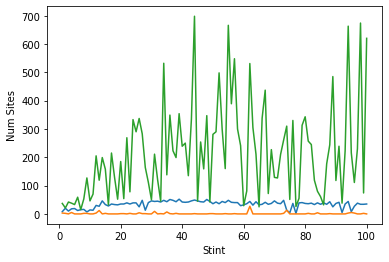

In [16]:
sns.lineplot(
    data=dfx,
    markers=True,
    x="Stint",
    y="Is Less Fit",
)
sns.lineplot(
    data=dfx,
    markers=True,
    x="Stint",
    y="Is More Fit",
)
sns.lineplot(
    data=dfx,
    markers=True,
    x="Stint",
    y="Is Neutral",
)
plt.gca().set_ylabel("Num Sites")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.439
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     37.92
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           6.82e-13
Time:                        15:05:52   Log-Likelihood:                -360.63
No. Observations:                 100   AIC:                             727.3
Df Residuals:                      97   BIC:                             735.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.0434      2.694      5.212      0.0

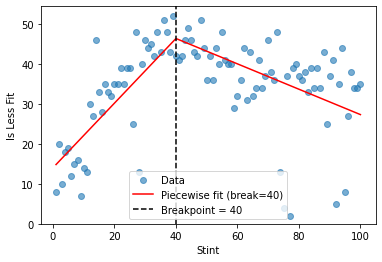

In [17]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Data
x = dfx["Stint"].values
y = dfx["Is Less Fit"].values

# Define breakpoint
c = 40

# Create piecewise regressor: slope changes after c
X = np.column_stack([
    x,
    np.where(x > c, x - c, 0)  # additional slope after breakpoint
])
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()
print(model.summary())

# Predict for plotting
x_grid = np.linspace(x.min(), x.max(), 200)
X_grid = np.column_stack([
    x_grid,
    np.where(x_grid > c, x_grid - c, 0)
])
X_grid = sm.add_constant(X_grid)
y_grid = model.predict(X_grid)

# Plot
plt.scatter(x, y, alpha=0.6, label="Data")
plt.plot(x_grid, y_grid, color="red", label=f"Piecewise fit (break=40)")
plt.axvline(c, color="black", linestyle="--", label="Breakpoint = 40")
plt.xlabel("Stint")
plt.ylabel("Is Less Fit")
plt.legend()
plt.ylim(0, None)
plt.show()


In [18]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

x = dfx["Stint"].values
y = dfx["Is Less Fit"].values

# -------------------------------
# Restricted model: single slope
# -------------------------------
X1 = sm.add_constant(x)
restricted = sm.OLS(y, X1).fit()

# -------------------------------
# Full model: breakpoint at 40
# -------------------------------
c = 40
X2 = np.column_stack([
    x,
    np.where(x > c, x - c, 0)  # slope change after breakpoint
])
X2 = sm.add_constant(X2)
full = sm.OLS(y, X2).fit()

# -------------------------------
# Compare models: nested F-test
# -------------------------------
f_test = full.compare_f_test(restricted)
print("F-test result:", f_test)


F-test result: (70.69738023404346, 3.6147100737741764e-13, 1.0)


In [19]:
import piecewise_regression

pw_fit = piecewise_regression.Fit(
    dfx["Stint"].to_list(),
    dfx["Is Less Fit"].to_list(),
    start_values=[40],
)
pw_fit.summary()



                    Breakpoint Regression Results                     
No. Observations                      100
No. Model Parameters                    4
Degrees of Freedom                     96
Res. Sum of Squares                7619.3
Total Sum of Squares              14151.4
R Squared                        0.461587
Adjusted R Squared               0.438917
Converged:                           True
                    Estimate      Std Err            t        P>|t|       [0.025       0.975]
----------------------------------------------------------------------------------------------------
const                11.2254         3.17       3.5374      0.000624       4.9263       17.524
alpha1               1.01705        0.163       6.2448      1.15e-08      0.69377       1.3403
beta1               -1.28387        0.172      -7.4508             -      -1.6259     -0.94183
breakpoint1           34.128          3.0            -             -       28.181       40.075
-----------------

'\n                    Breakpoint Regression Results                     \n====================================================================================================\nNo. Observations                      100\nNo. Model Parameters                    4\nDegrees of Freedom                     96\nRes. Sum of Squares                7619.3\nTotal Sum of Squares              14151.4\nR Squared                        0.461587\nAdjusted R Squared               0.438917\nConverged:                           True\n====================================================================================================\n====================================================================================================\n                    Estimate      Std Err            t        P>|t|       [0.025       0.975]\n----------------------------------------------------------------------------------------------------\nconst                11.2254         3.17       3.5374      0.000624       4.9

teeplots/2025-11-30-genme-complexity-regression/viz=plot-breakpoints+x=stint+y=genome_complexity+ext=.pdf
teeplots/2025-11-30-genme-complexity-regression/viz=plot-breakpoints+x=stint+y=genome_complexity+ext=.png


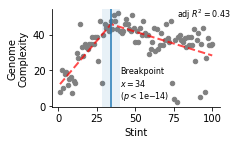

In [20]:
pw_fit.plot_data(color="grey", s=20)
# Pass in standard matplotlib keywords to control any of the plots
pw_fit.plot_fit(
    color="red",
    linewidth=2,
    alpha=0.7,
    ls="--",
)
with tp.teed(
    pw_fit.plot_breakpoints,
    teeplot_subdir=teeplot_subdir,
    teeplot_outattrs={
        "x": "stint",
        "y": "genome_complexity",
    }
) as ax:
    pw_fit.plot_breakpoint_confidence_intervals()
    plt.xlabel("Stint")
    plt.ylabel("Genome\nComplexity")
    plt.gcf().set_size_inches(3, 1.8)

    # annotate breakpoint probability
    plt.text(77, 50, "adj $R^2=0.43$", fontsize=8)
    plt.text(40, 4, "Breakpoint\n$x=34$\n($p<1\mathrm{e}{-14}$)", fontsize=8)
    sns.despine(ax=ax)
